Neurometric response functions relating single-neuron activity to both phonetic content and subsequent behavioral choice.
Compare two neural responses:
1. early phonetic response
2. late feedback response
in the same electrodes.

In [1]:
from pathlib import Path
import re
from typing import Any, TypeAlias

from loguru import logger as L
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import polars as pl
import polars_ds as pds
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
import seaborn as sns
import torch
from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
%load_ext autoreload
%autoreload 2

In [128]:
from src.data import add_metadata_features
from src.stimuli import OFFSET_DICT, POD_dict, WORD_END_TO_PHONEME_PAIR

In [4]:
sns.set_context("paper", font_scale=2)

In [5]:
all_epochs = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))

# Behavioral decoding searchlight
A_behav_predictions = list(Path("outputs/causal4/behavior_decoding_single_electrode_summarize").glob("*/A-predictions.parquet"))
A_early_behav_predictions = list(Path("outputs/causal4/behavior_decoding_single_electrode_summarize").glob("*/A_early-predictions.parquet"))

# phonetic decoding searchlight. NB this is currently only done for behaviorally selective sites
# TODO broaden
phon_predictions_path = Path("outputs/causal4/A_predictions/behavior_to_phonetic_decoding.parquet")

epoch_tmin = -0.4
epoch_sfreq = 100

# parameters for searching for behavioral peaks
behav_response_tmin_min = 0.3
behav_response_tmax_max = 1.3
behav_response_smin_min = (behav_response_tmin_min - epoch_tmin) * epoch_sfreq
behav_response_smax_max = (behav_response_tmax_max - epoch_tmin) * epoch_sfreq

# parameters for searching for phonetic peaks
phon_response_tmin_min = 0.0
phon_response_tmax_max = 0.3
phon_response_smin_min = (phon_response_tmin_min - epoch_tmin) * epoch_sfreq
phon_response_smax_max = (phon_response_tmax_max - epoch_tmin) * epoch_sfreq
# threshold value for significant phonetic decoding peak
phon_response_peak_threshold = 0.7

all_response_tmax_max = 1.3
assert all_response_tmax_max >= behav_response_tmax_max
assert all_response_tmax_max >= phon_response_tmax_max
all_response_smax_max = int((all_response_tmax_max - epoch_tmin) * epoch_sfreq)

relative_performance_twidth = 0.2
relative_performance_swidth = int(relative_performance_twidth * epoch_sfreq)

outdir = "."

max_plot_rows = 15
phoneme_pair_order = ["bm", "dn", "pb"]
source_order = ["phon", "behav"]

subject_enum = pl.Enum([
    "EC237", "EC243", "EC248", "EC250", "EC253", "EC260",
    "EC270", "EC278", "EC279", "EC282", "EC287"
])
phoneme_pair_enum = pl.Enum(phoneme_pair_order)
word_end_enum = pl.Enum(list(OFFSET_DICT.keys()))

## Prepare helpers

In [6]:
def pl_roc_auc(df: pl.DataFrame, target_col: str, proba_col: str, group_cols: list[str],
               roc_auc_name="roc_auc") -> pl.DataFrame:
    return (
        df.with_columns(
            pl.col(proba_col)
            .rank(method="average")
            .over(group_cols)
            .alias("rank")
        )
        .group_by(group_cols) \
        .agg(
            n_pos = pl.col(target_col).sum(),
            n = pl.len(),
            rank_sum_pos = pl.col("rank")
                .filter(pl.col(target_col) == 1)
                .sum(),
        )
        .with_columns(
            n_neg = (pl.col("n") - pl.col("n_pos"))
        )
        .with_columns(
            **{roc_auc_name: pl.when((pl.col("n_pos") > 0) & (pl.col("n_neg") > 0))
                .then(
                    (pl.col("rank_sum_pos") - pl.col("n_pos") * (pl.col("n_pos") + 1) / 2)
                    / (pl.col("n_pos") * pl.col("n_neg"))
                ).otherwise(None)}
        )
        .select(group_cols + [roc_auc_name])
    )

In [142]:
word_end_df = pl.from_pandas(
    pd.DataFrame.from_dict(OFFSET_DICT, orient="index", columns=["word_end_offset"]).rename_axis("word_end") \
        .join(pd.DataFrame.from_dict(WORD_END_TO_PHONEME_PAIR, orient="index", columns=["phoneme_pair"]).rename_axis("word_end"),
              on="word_end").reset_index()) \
    .with_columns(
        pl.col("word_end").cast(word_end_enum),
        pl.col("phoneme_pair").cast(phoneme_pair_enum),
        ((pl.col("word_end_offset") - epoch_tmin) * epoch_sfreq).alias("word_end_offset_sample")
    )

## Behav prep

In [7]:
behav_pred_df = pd.concat([pd.read_parquet(f) for f in A_behav_predictions + A_early_behav_predictions])

In [8]:
behav_pred_df = pl.concat([pl.read_parquet(f) for f in A_behav_predictions + A_early_behav_predictions]) \
    .with_columns(pl.col("subject").cast(subject_enum),
                  pl.col("phoneme_pair").cast(phoneme_pair_enum),
                  pl.col("word_end").cast(word_end_enum),
                  (pl.col("decoder_target") == 1).cast(pl.Int8).alias("decoder_target"))

### Find behav peaks

In [9]:
# Compute behavioral baselines
behav_baseline_df = pl_roc_auc(
    df=behav_pred_df.unique(subset=["subject", "electrode_idx", "phoneme_pair", "word_end", "epoch_idx", "fold"], keep="first"),
    target_col="decoder_target",
    proba_col="baseline_decoder_proba",
    group_cols=["subject", "electrode_idx", "phoneme_pair", "word_end", "fold"],
    roc_auc_name="behav_roc_auc_baseline"
)

In [10]:
# # Compute per-window, per-fold behavioral prediction performance
# # Exclude the late time windows we don't care about
# # Include the early time windows for now; these will be reused in later comparison analyses
# behav_roc_auc_searchlight = behav_pred_df \
#     [behav_pred_df.smax <= all_response_smax_max] \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax", "fold"]) \
#     .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.full_decoder_proba))

In [11]:
# Compute per-window, per-fold behavioral prediction performance
# Exclude the late time windows we don't care about
# Include the early time windows for now; these will be reused in later comparison analyses
group_cols = ["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax", "fold"]
behav_roc_auc_searchlight = pl_roc_auc(
    df=behav_pred_df.filter(pl.col("smax") <= all_response_smax_max),
    target_col="decoder_target",
    proba_col="full_decoder_proba",
    group_cols=group_cols,
    roc_auc_name="behav_roc_auc")

In [12]:
behav_roc_auc_searchlight_df = behav_roc_auc_searchlight \
    .join(behav_baseline_df, on=["subject", "electrode_idx", "phoneme_pair", "word_end", "fold"], how="inner") \
    .with_columns(
        (pl.col("behav_roc_auc") - pl.col("behav_roc_auc_baseline")).alias("behav_roc_auc_improvement")
    )

In [13]:
behav_roc_auc_mean_df = behav_roc_auc_searchlight_df \
    .group_by(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]) \
    .agg(
        [pl.col("behav_roc_auc").mean(),
         pl.col("behav_roc_auc_baseline").mean(),
         pl.col("behav_roc_auc_improvement").mean(),
    ])

In [147]:
behav_peaks_df = (
    behav_roc_auc_mean_df
    .join(word_end_df, on=["phoneme_pair", "word_end"], how="left")
    .filter(pl.col("smax") <= pl.col("word_end_offset_sample"),
            pl.col("smin") >= behav_response_smin_min)
    .sort("behav_roc_auc_improvement", descending=True)
    .group_by(["subject", "electrode_idx", "phoneme_pair", "word_end"])
    .first()
    .filter(pl.col("behav_roc_auc_improvement") > 0)
)

In [15]:
# behav_roc_auc_searchlight_df = pd.merge(
#     behav_roc_auc_searchlight.rename("behav_roc_auc"),
#     behav_baseline_df.rename("behav_roc_auc_baseline"),
#     left_index=True, right_index=True).reset_index()
# assert behav_roc_auc_searchlight_df.shape[0] == behav_roc_auc_searchlight.shape[0]
# behav_roc_auc_searchlight_df["behav_roc_auc_improvement"] = \
#     behav_roc_auc_searchlight_df.behav_roc_auc - behav_roc_auc_searchlight_df.behav_roc_auc_baseline

In [16]:
# # Get mean roc-auc across folds
# behav_roc_auc_mean_df = behav_roc_auc_searchlight_df \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]) \
#     [["behav_roc_auc", "behav_roc_auc_baseline", "behav_roc_auc_improvement"]].mean().reset_index()

In [17]:
# # Compute behavioral peaks within the relevant search window.
# behav_peaks_df = behav_roc_auc_mean_df \
#     [behav_roc_auc_mean_df.smin >= behav_response_smin_min] \
#     .sort_values("behav_roc_auc_improvement", ascending=False) \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "word_end"]) \
#     .first().reset_index()

## Prep phonetic

In [18]:
phon_pred_df = pl.read_parquet(phon_predictions_path) \
    .with_columns(pl.col("subject").cast(subject_enum),
                  pl.col("phoneme_pair").cast(phoneme_pair_enum),
                  (pl.col("decoder_target") == 1).cast(pl.Int8).alias("decoder_target"))

In [19]:
# Compute per-window, per-fold phonetic prediction performance
# Exclude the late time windows we don't care about
# Include the rest of time windows for now; these will be reused in later comparison analyses
group_cols = ["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "fold"]
phon_roc_auc_searchlight_df = pl_roc_auc(
    df=phon_pred_df.filter((pl.col("smin") >= phon_response_smin_min) & (pl.col("smax") <= all_response_smax_max)),
    target_col="decoder_target",
    proba_col="decoder_proba",
    group_cols=group_cols,
    roc_auc_name="phon_roc_auc"
)

In [153]:
phon_roc_auc_mean_df = phon_roc_auc_searchlight_df \
    .group_by(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]) \
    .agg(pl.col("phon_roc_auc").mean())

In [154]:
phon_peaks_df = (
    phon_roc_auc_mean_df
    .join(word_end_df.group_by(["phoneme_pair"]).agg(pl.max("word_end_offset_sample")), on=["phoneme_pair"], how="left")
    .filter(pl.col("smin") >= phon_response_smin_min,
            pl.col("smax") <= pl.col("word_end_offset_sample"),
            # pl.col("smax") <= phon_response_smax_max,
            pl.col("phon_roc_auc") >= phon_response_peak_threshold)
    .sort("phon_roc_auc", descending=True)
    .group_by(["subject", "electrode_idx", "phoneme_pair"])
    .first()
)

In [22]:
# phon_pred_df = pd.read_parquet(phon_predictions_path) \
#     .astype({"subject": "category", "phoneme_pair": "category"})

In [23]:
# # Compute per-window, per-fold phonetic prediction performance
# # Exclude the late time windows we don't care about
# # Include the rest of time windows for now; these will be reused in later comparison analyses
# phon_roc_auc_searchlight_df = phon_pred_df \
#     .query("smin >= @phon_response_smin_min and smax <= @all_response_smax_max") \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "fold"]) \
#     .progress_apply(lambda xs: roc_auc_score(xs.decoder_target, xs.decoder_proba)) \
#     .rename("phon_roc_auc").reset_index()

In [24]:
# phon_roc_auc_mean_df = phon_roc_auc_searchlight_df \
#     .groupby(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]) \
#     [["phon_roc_auc"]].mean().reset_index()

In [25]:
# # Compute phonetic peaks within the relevant search window, averaging ROC-AUC over folds.
# phon_peaks_df = phon_roc_auc_mean_df \
#     [(phon_roc_auc_mean_df.smin >= phon_response_smin_min) &
#      (phon_roc_auc_mean_df.smax <= phon_response_smax_max)] \
#     .query("phon_roc_auc >= @phon_response_peak_threshold") \
#     .sort_values("phon_roc_auc", ascending=False) \
#     .groupby(["subject", "electrode_idx", "phoneme_pair"]) \
#     .first().reset_index()

## Prepare epochs

In [26]:
epochs = {}
for path in all_epochs:
    subject = re.findall(r"(EC[\d]+)_epo", str(path))[0]
    ep_i = mne.read_epochs(path, verbose=False)
    ep_i.metadata = add_metadata_features(ep_i.metadata)
    epochs[subject] = ep_i

Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 107 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns
Replacing existing metadata with 106 columns


In [27]:
all_md = pl.from_pandas(
    pd.concat([ep.metadata.rename_axis("epoch_idx").assign(subject=subject).reset_index()
               for subject, ep in epochs.items()], ignore_index=True).drop(columns=["TDT Block"])) \
    .with_columns(pl.col("subject").cast(subject_enum),
                  pl.col("phoneme_pair").cast(phoneme_pair_enum),
                  pl.col("word_end").cast(word_end_enum))

## Plot neurometric for phonetic targets

In [155]:
# --- phon peaks: keys -> join to predictions -> join metadata
plot_phon_phon_keys = phon_peaks_df.select(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"])
plot_phon_phon_df = (
    plot_phon_phon_keys
    .join(phon_pred_df,
          on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
          how="left")
    .join(all_md,
          on=["subject", "epoch_idx", "phoneme_pair"],
          how="left")
)


In [156]:
# --- behav peaks: keys (+ word_end) -> rename -> join to predictions -> join metadata
plot_behav_phon_keys = behav_peaks_df.select(
    ["subject", "electrode_idx", "phoneme_pair", "smin", "smax", "word_end"]
)

plot_behav_phon_df = (
    plot_behav_phon_keys
    .rename({"word_end": "behav_word_end"})
    .join(
        phon_pred_df,
        on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
        how="left",
    )
    .join(
        all_md,
        on=["subject", "epoch_idx", "phoneme_pair"],
        how="left",
    )
    # retain epochs where metadata word_end matches behav peak word_end
    .filter(pl.col("word_end") == pl.col("behav_word_end"))
    .drop("behav_word_end")
)

In [157]:
# --- concat with source labels
plot_phon_df = pl.concat(
    [
        plot_phon_phon_df.with_columns(pl.lit("phon").alias("source")),
        plot_behav_phon_df.with_columns(pl.lit("behav").alias("source")),
    ],
    how="vertical",
).with_columns(
    pl.concat_str(
        [pl.col("subject"), pl.col("electrode_idx").cast(pl.Utf8), pl.col("phoneme_pair")],
        separator="_"
    ).alias("site")
)

# --- asserts
assert plot_phon_df.select(pl.col("resampled").is_null().any()).item() is False
assert plot_phon_df.select(pl.col("fold").is_null().any()).item() is False

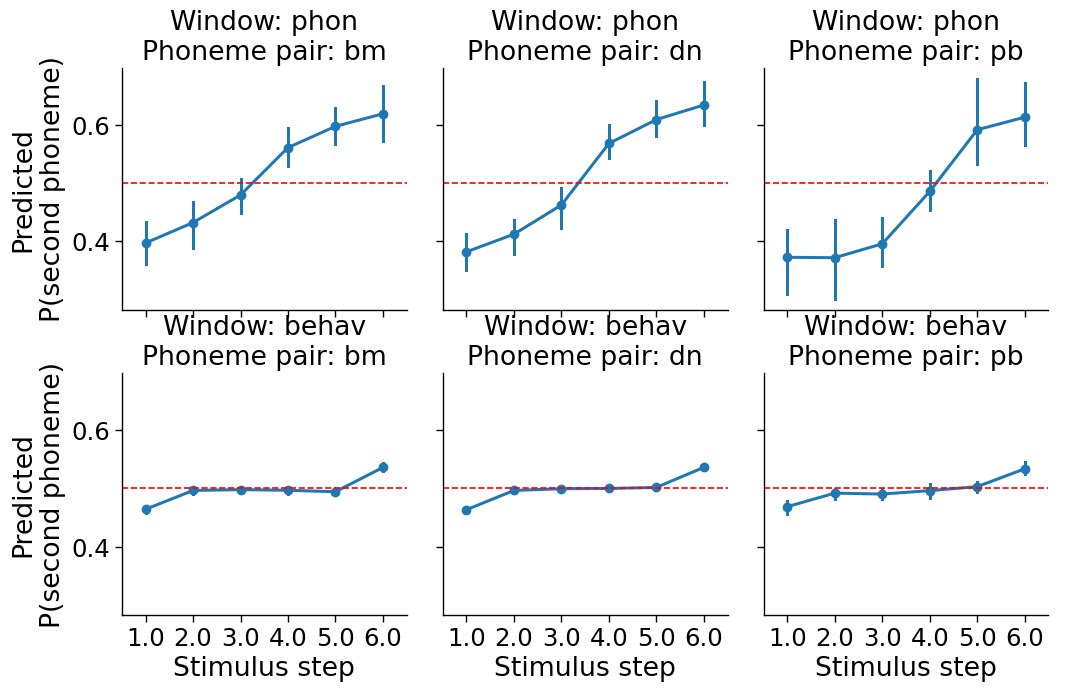

In [205]:
g = sns.catplot(data=plot_phon_df.to_pandas(),
                x="resampled", y="decoder_proba",
                # hue="lexical_evidence",
                col="phoneme_pair", col_order=phoneme_pair_order,
                row="source", row_order=["phon", "behav"],
                kind="point", units="site",
                height=3.5)
g.set_axis_labels("Stimulus step", "Predicted\nP(second phoneme)")
g.set_titles(template="Window: {row_name}\nPhoneme pair: {col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [159]:
# compute phonetic accuracy per source and resampled, within fold
phon_acc = (plot_phon_df
 .with_columns(
     ((pl.col("decoder_target") == 1) == (pl.col("decoder_proba") >= 0.5))
     .cast(pl.Float32).alias("correct")
 )
 .group_by(["source", "site", "subject", "electrode_idx", "phoneme_pair", "lexical_evidence", "resampled", "fold"])
 .agg(pl.col("correct").mean().alias("accuracy")))

In [160]:
phon_acc_change = (phon_acc
    .pivot(
        values="accuracy",
        index=["site", "subject", "electrode_idx", "phoneme_pair",
            "resampled", "lexical_evidence", "fold"],
        on="source",
        aggregate_function="first"
    )
    .drop_nulls(["phon", "behav"])
    .with_columns(
        (pl.col("phon") - pl.col("behav")).alias("acc_diff")
    )
)

In [161]:
# # compute phonetic accuracy per source and resampled, within fold
# phon_acc = plot_phon_df.groupby(["source", "site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "smin", "smax", "fold"]) \
#     .progress_apply(lambda xs: accuracy_score(xs.decoder_target == 1, xs.decoder_proba > 0.5)) \
#     .rename("accuracy").reset_index()

In [162]:
# # Pivot wider and get difference in accuracy depending on phon source vs behav source
# assert phon_acc.groupby(["site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "fold"]).size().max() <= 2

# # NB we are doing dropna here -- so those phon sites which are predictive of phon but
# # not predictive of behav aren't included in the comparison
# phon_acc_change = phon_acc.pivot_table(
#     index=["site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "fold"],
#     columns="source",
#     values="accuracy").dropna().assign(acc_diff=lambda df: df.phon - df.behav)

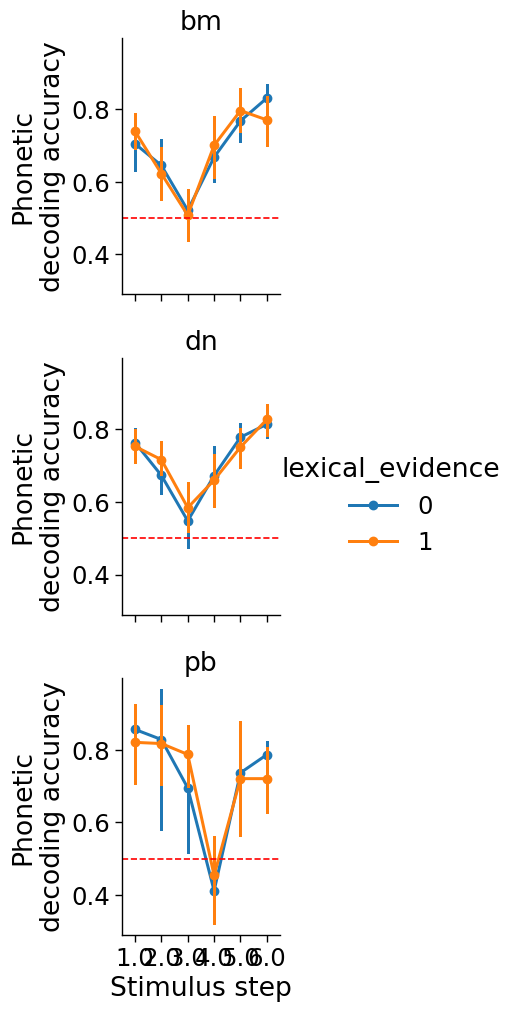

In [163]:
g = sns.catplot(data=phon_acc_change.to_pandas(),
                x="resampled", y="phon", hue="lexical_evidence",
                row="phoneme_pair", row_order=phoneme_pair_order,
                kind="point", units="site", height=3.5)
g.set_axis_labels("Stimulus step", "Phonetic\ndecoding accuracy")
g.set_titles(template="{row_name}")
for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

/tmp/ipykernel_1332755/2544901511.py:2: DeprecationWarning: `DataFrame.melt` is deprecated. Use `unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  data=phon_acc_change.melt(


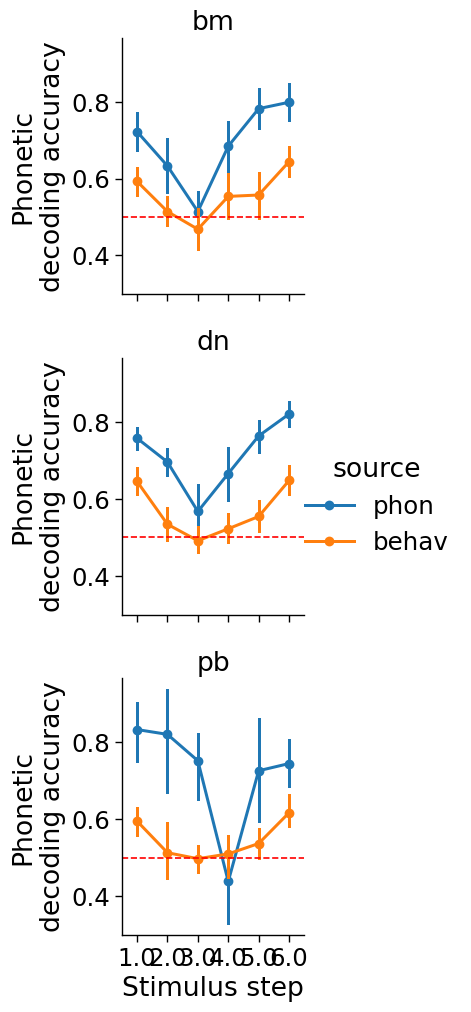

In [164]:
g = sns.catplot(
    data=phon_acc_change.melt(
        id_vars=["site", "subject", "electrode_idx", "phoneme_pair", "resampled", "lexical_evidence", "fold"],
        value_vars=["phon", "behav"],
        variable_name="source",
        value_name="accuracy"),
    x="resampled", y="accuracy", hue="source", hue_order=source_order,
    row="phoneme_pair", row_order=phoneme_pair_order,
    kind="point", units="site", height=3.5)
g.set_axis_labels("Stimulus step", "Phonetic\ndecoding accuracy")
g.set_titles(template="{row_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [165]:
# from scipy.stats import ttest_1samp
# phon_acc_change.groupby(["phoneme_pair", "resampled", "lexical_evidence"]) \
#     .apply(lambda xs: pd.Series(ttest_1samp(xs["phon"], popmean=0.5), index=["t_stat", "p_value"])).sort_values("p_value")

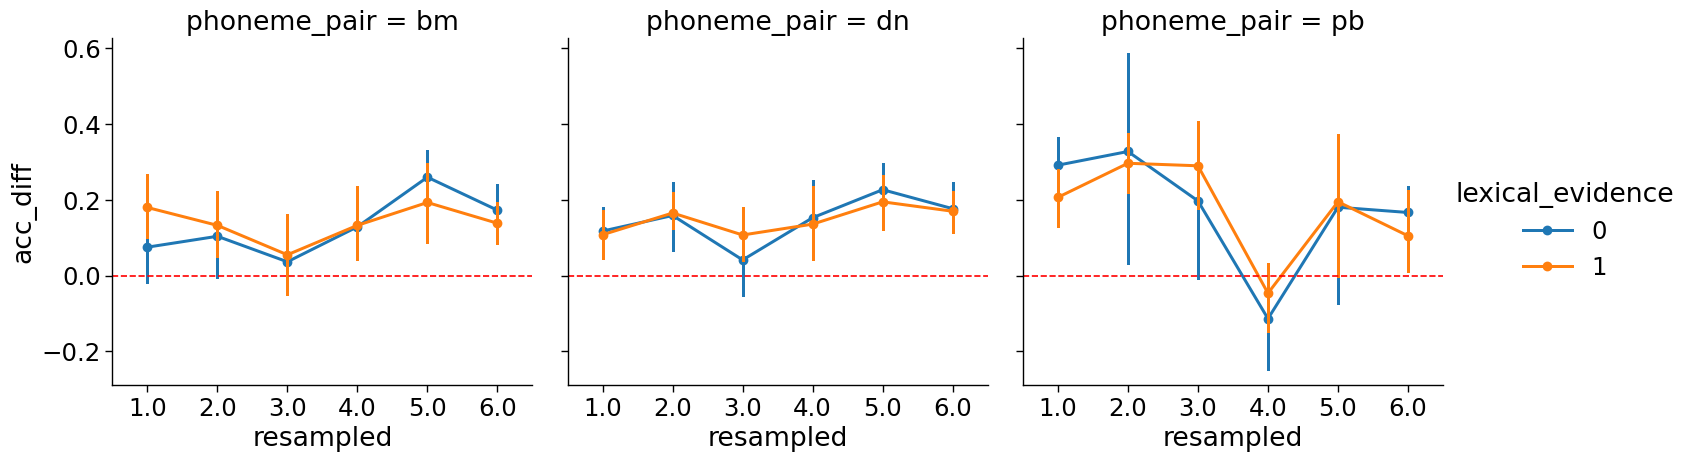

In [166]:
g = sns.catplot(data=phon_acc_change.to_pandas(),
                x="resampled", y="acc_diff", hue="lexical_evidence",
                col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

In [167]:
# from scipy.stats import ttest_1samp
# phon_acc_change.groupby(["phoneme_pair", "resampled", "lexical_evidence"]) \
#     .apply(lambda xs: pd.Series(ttest_1samp(xs["acc_diff"], popmean=0), index=["t_stat", "p_value"])).sort_values("p_value")

## Behav prediction

In [168]:
plot_phon_behav_keys = phon_peaks_df.select(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"])
plot_phon_behav_df = plot_phon_behav_keys.join(
    behav_pred_df,
    on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
    how="left")
missing_phon_behav = plot_phon_behav_df.filter(pl.col("full_decoder_proba").is_null())
if missing_phon_behav.height > 0:
    L.warning(f"Found {missing_phon_behav.height} phonetic peak sites with no matching behavioral predictions")
    L.warning(missing_phon_behav.select(["subject", "electrode_idx", "phoneme_pair", "smin", "smax"]))

plot_behav_behav_keys = (
    behav_peaks_df
    .select(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"])
)
plot_behav_behav_df = plot_behav_behav_keys.join(
    behav_pred_df,
    on=["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"],
    how="left"
)
missing_behav_behav = plot_behav_behav_df.filter(pl.col("full_decoder_proba").is_null())
if missing_behav_behav.height > 0:
    L.warning(f"Found {missing_behav_behav.height} behavioral peak sites with no matching behavioral predictions")
    L.warning(missing_behav_behav.select(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"]))

2026-01-30 16:28:56.209 | WARNING  | __main__:<module>:8 - Found 9 phonetic peak sites with no matching behavioral predictions
2026-01-30 16:28:56.211 | WARNING  | __main__:<module>:9 - shape: (9, 5)
┌─────────┬───────────────┬──────────────┬──────┬──────┐
│ subject ┆ electrode_idx ┆ phoneme_pair ┆ smin ┆ smax │
│ ---     ┆ ---           ┆ ---          ┆ ---  ┆ ---  │
│ enum    ┆ i64           ┆ enum         ┆ i64  ┆ i64  │
╞═════════╪═══════════════╪══════════════╪══════╪══════╡
│ EC282   ┆ 101           ┆ dn           ┆ 59   ┆ 74   │
│ EC253   ┆ 52            ┆ dn           ┆ 61   ┆ 76   │
│ EC250   ┆ 215           ┆ bm           ┆ 57   ┆ 72   │
│ EC282   ┆ 117           ┆ dn           ┆ 55   ┆ 70   │
│ EC260   ┆ 219           ┆ dn           ┆ 57   ┆ 72   │
│ EC278   ┆ 121           ┆ dn           ┆ 65   ┆ 80   │
│ EC243   ┆ 103           ┆ dn           ┆ 67   ┆ 82   │
│ EC282   ┆ 104           ┆ dn           ┆ 59   ┆ 74   │
│ EC282   ┆ 117           ┆ bm           ┆ 63   ┆ 78   │
└─

In [169]:
plot_behav_df = pl.concat(
    [
        plot_phon_behav_df.with_columns(pl.lit("phon").alias("source")),
        plot_behav_behav_df.with_columns(pl.lit("behav").alias("source")),
    ],
    how="align",
).with_columns(
    pl.concat_str(
        [pl.col("subject"), pl.col("electrode_idx").cast(pl.Utf8), pl.col("phoneme_pair")],
        separator="_"
    ).alias("site")
).join(all_md, on=["subject", "epoch_idx", "phoneme_pair", "word_end"], how="left")

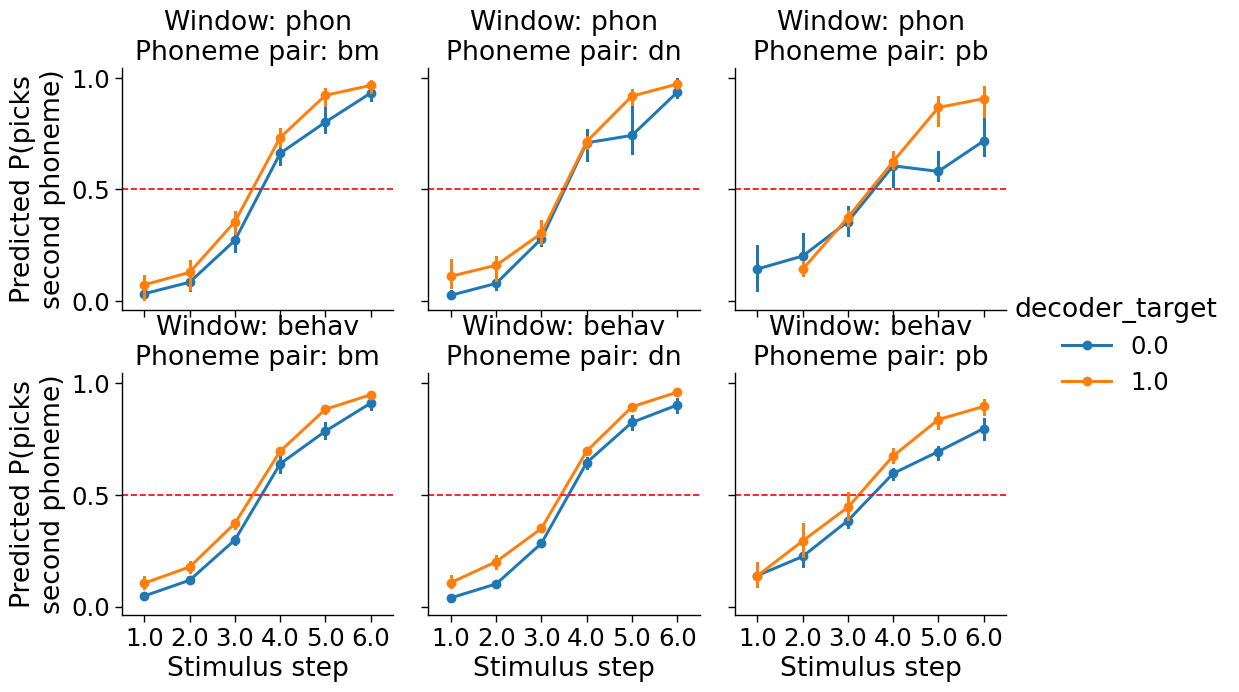

In [170]:
g = sns.catplot(data=plot_behav_df.to_pandas(),
                x="resampled", y="full_decoder_proba", hue="decoder_target",
                col="phoneme_pair", col_order=phoneme_pair_order,
                row="source", row_order=["phon", "behav"],
                kind="point", units="site",
                height=3.5)
g.set_axis_labels("Stimulus step", "Predicted P(picks\nsecond phoneme)")
g.set_titles(template="Window: {row_name}\nPhoneme pair: {col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

In [171]:
behav_roc_auc = pl_roc_auc(
    df=plot_behav_df,
    target_col="decoder_target",
    proba_col="full_decoder_proba",
    group_cols=["source", "site", "subject", "electrode_idx", "phoneme_pair", "word_end", "resampled", "smin", "smax", "fold"],
    roc_auc_name="behav_roc_auc"
).join(
    pl_roc_auc(
        df=plot_behav_df,
        target_col="decoder_target",
        proba_col="baseline_decoder_proba",
        group_cols=["source", "site", "subject", "electrode_idx", "phoneme_pair", "word_end", "resampled", "smin", "smax", "fold"],
        roc_auc_name="behav_roc_auc_baseline"),
    on=["source", "site", "subject", "electrode_idx", "phoneme_pair", "word_end", "resampled", "smin", "smax", "fold"],
    how="inner"
).with_columns(
    (pl.col("behav_roc_auc") - pl.col("behav_roc_auc_baseline")).alias("behav_roc_auc_improvement"),
    pl.concat_str(
        [pl.col("subject"), pl.col("electrode_idx").cast(pl.Utf8), pl.col("phoneme_pair")],
        separator="_"
    ).alias("site")
)

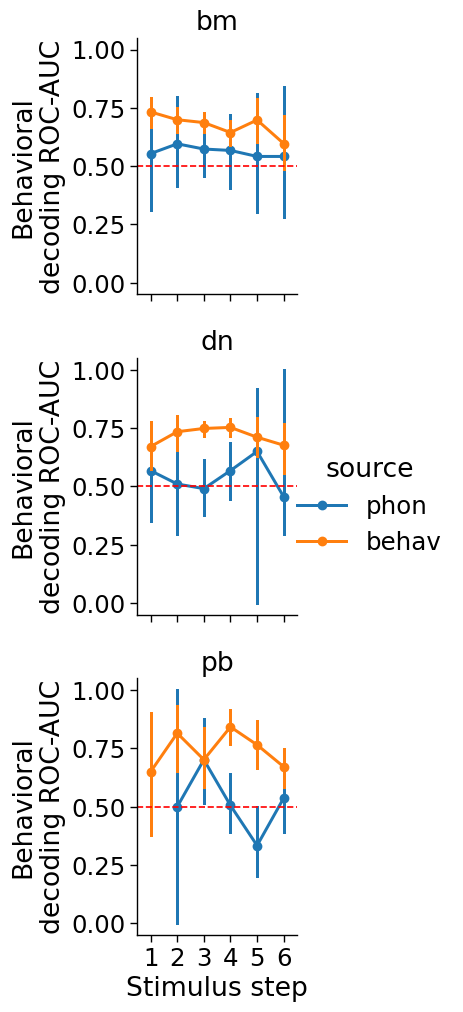

In [172]:
g = sns.catplot(data=behav_roc_auc.to_pandas().astype({"resampled": int}),
                x="resampled", y="behav_roc_auc",
                hue="source", hue_order=source_order,
                row="phoneme_pair", row_order=phoneme_pair_order,
                kind="point", units="site", height=3.5)
g.set_axis_labels("Stimulus step", "Behavioral\ndecoding ROC-AUC")
g.set_titles(template="{row_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")

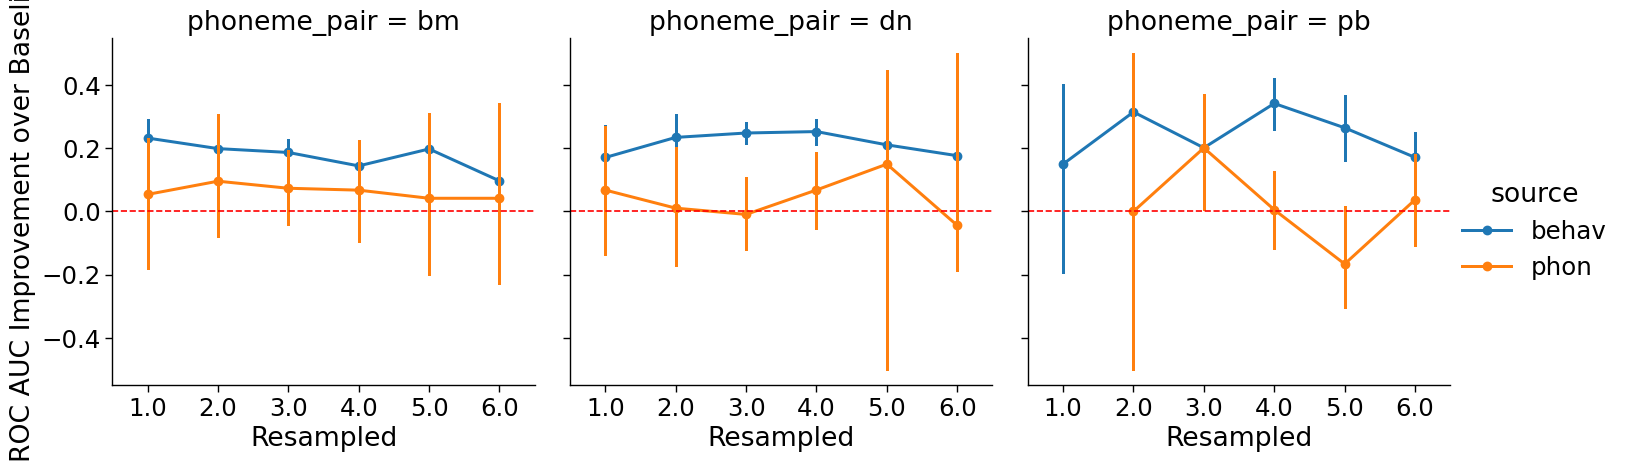

In [ ]:
g = sns.catplot(data=behav_roc_auc.to_pandas(), x="resampled", y="behav_roc_auc_improvement",
                hue="source", hue_order=source_order, col="phoneme_pair", col_order=phoneme_pair_order,
                kind="point", units="site")
g.set_axis_labels("Resampled", "ROC AUC Improvement over Baseline")

for ax in g.axes.flat:
    ax.axhline(0, color="red", linestyle="--")

## Dynamics

### Peak timing

In [174]:
peak_timing_plot = pl.concat([
    phon_peaks_df.with_columns(pl.lit("phon").alias("source")),
    behav_peaks_df.with_columns(pl.lit("behav").alias("source")),
], how="align").with_columns(
    (((pl.col("smin") + pl.col("smax")) / 2) / epoch_sfreq + epoch_tmin).alias("t_center")
)

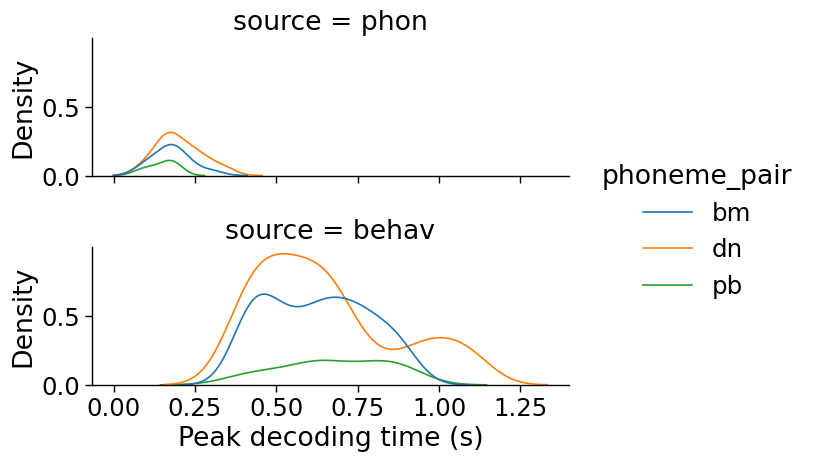

In [175]:
g = sns.displot(data=peak_timing_plot.to_pandas(), x="t_center",
                hue="phoneme_pair", hue_order=phoneme_pair_order,
                row="source", row_order=source_order,
                kind="kde", clip=(0, None),
                height=2.5, aspect=2.5)
g.set_axis_labels("Peak decoding time (s)", "Density")

### Peak timing of behavior relative to word offset

In [176]:
behav_peak_timing_plot = behav_peaks_df.with_columns(
    (((pl.col("smin") + pl.col("smax")) / 2) / epoch_sfreq + epoch_tmin).alias("t_center"),
    pl.col("word_end").replace_strict(OFFSET_DICT).alias("t_offset"),
    pl.col("phoneme_pair").replace_strict(POD_dict).alias("t_pod")
).with_columns(
    (pl.col("t_center") - pl.col("t_offset")).alias("t_from_offset"),
    (pl.col("t_center") - pl.col("t_pod")).alias("t_from_pod")
)

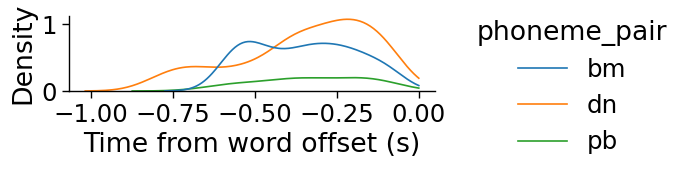

In [203]:
g = sns.displot(data=behav_peak_timing_plot.to_pandas(), x="t_from_offset",
                hue="phoneme_pair", hue_order=phoneme_pair_order,
                # hue="subject",
                kind="kde", clip=(None, 0),
                height=2, aspect=2.5)
g.set_axis_labels("Time from word offset (s)", "Density")

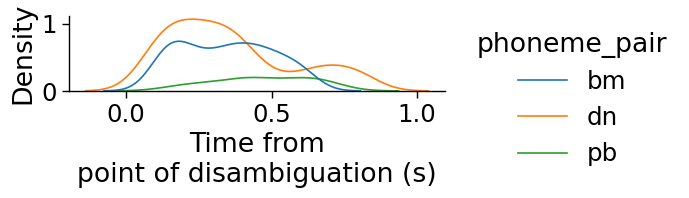

In [178]:
g = sns.displot(data=behav_peak_timing_plot.to_pandas(), x="t_from_pod",
                hue="phoneme_pair", hue_order=phoneme_pair_order,
                # hue="subject",
                kind="kde",
                height=2, aspect=2.5)
g.set_axis_labels("Time from\npoint of disambiguation (s)", "Density")

In [179]:
(
    behav_peak_timing_plot
    .group_by(["subject", "phoneme_pair"])
    .agg(pl.col("t_from_offset").var(), pl.col("t_from_pod").var())
    .unpivot(index=["subject", "phoneme_pair"],
             on=["t_from_offset", "t_from_pod"],
             variable_name="time_reference",
             value_name="variance")
)

subject,phoneme_pair,time_reference,variance
enum,enum,str,f64
"""EC250""","""bm""","""t_from_offset""",0.028089
"""EC243""","""dn""","""t_from_offset""",0.0497
"""EC279""","""bm""","""t_from_offset""",0.03067
"""EC278""","""dn""","""t_from_offset""",0.058972
"""EC287""","""pb""","""t_from_offset""",0.025765
…,…,…,…
"""EC278""","""pb""","""t_from_pod""",0.029821
"""EC270""","""pb""","""t_from_pod""",0.0265
"""EC260""","""bm""","""t_from_pod""",0.012467


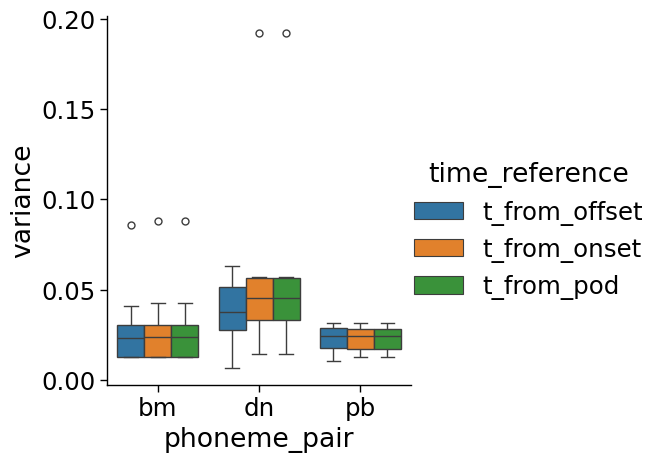

In [180]:
sns.catplot(data=
    pl.concat([
        (
            behav_peak_timing_plot
            .group_by(["subject", "phoneme_pair"])
            .agg(pl.col("t_from_offset").var(), pl.col("t_from_pod").var())
            .unpivot(index=["subject", "phoneme_pair"],
                    on=["t_from_offset", "t_from_pod"],
                    variable_name="time_reference",
                    value_name="variance")
        ),
        (
            peak_timing_plot
            .filter(pl.col("source") == "behav")
            .group_by(["subject", "phoneme_pair"])
            .agg(pl.col("t_center").var().alias("variance"))
            .with_columns(pl.lit("t_from_onset").alias("time_reference"))
        )], how="align"),
        x="phoneme_pair", order=phoneme_pair_order, y="variance",
        hue="time_reference", kind="box")

### Performance relative to peak

In [181]:
phon_relative_df = (
    phon_peaks_df
    .join(phon_roc_auc_mean_df, on=["subject", "electrode_idx", "phoneme_pair"], how="left")
    .with_columns(
        (pl.col("smin_right") - pl.col("smin")).alias("smin_relative"),
        (pl.col("smax_right") - pl.col("smax")).alias("smax_relative"),
        (pl.col("phon_roc_auc_right") / pl.col("phon_roc_auc")).alias("phon_roc_auc_relative"),
    )
    .with_columns(
        (pl.col("smax_relative") / epoch_sfreq).alias("tmax_relative")
    )
    .filter(
        pl.col("smin_relative") >= -relative_performance_swidth,
        pl.col("smax_relative") <= relative_performance_swidth,
        pl.col("phon_roc_auc_right") > 0.5
    )
)

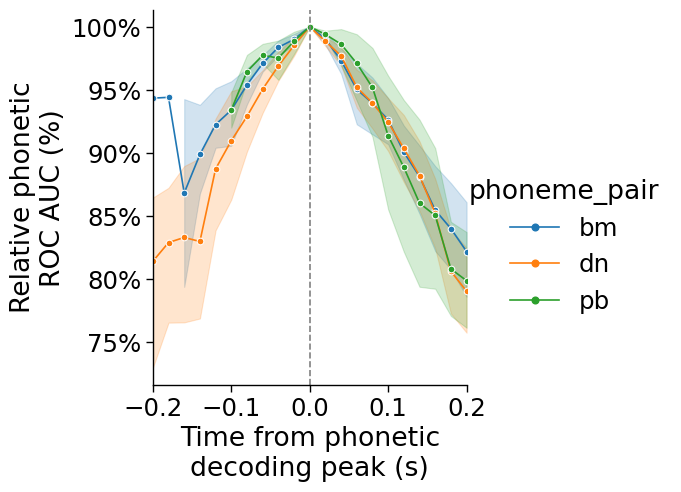

In [182]:
g = sns.relplot(data=phon_relative_df.to_pandas(), x="tmax_relative", y="phon_roc_auc_relative",
                hue="phoneme_pair", hue_order=phoneme_pair_order,
                kind="line", marker="o")
g.set_axis_labels("Time from phonetic\ndecoding peak (s)", "Relative phonetic\nROC AUC (%)")
for ax in g.axes.flat:
    ax.axvline(0, color="gray", ls="--")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.set_xlim(-relative_performance_twidth, relative_performance_twidth)

In [183]:
behav_relative_df = (
    behav_peaks_df
    .join(behav_roc_auc_mean_df, on=["subject", "electrode_idx", "phoneme_pair", "word_end"], how="left")
    .with_columns(
        (pl.col("smin_right") - pl.col("smin")).alias("smin_relative"),
        (pl.col("smax_right") - pl.col("smax")).alias("smax_relative"),
        (pl.col("behav_roc_auc_improvement_right") / pl.col("behav_roc_auc_improvement")).alias("behav_roc_auc_relative"),
    )
    .with_columns(
        (pl.col("smax_relative") / epoch_sfreq).alias("tmax_relative")
    )
    .filter(
        pl.col("smin_relative") >= -relative_performance_swidth,
        pl.col("smax_relative") <= relative_performance_swidth,
        pl.col("behav_roc_auc_improvement_right") > 0
    )
)

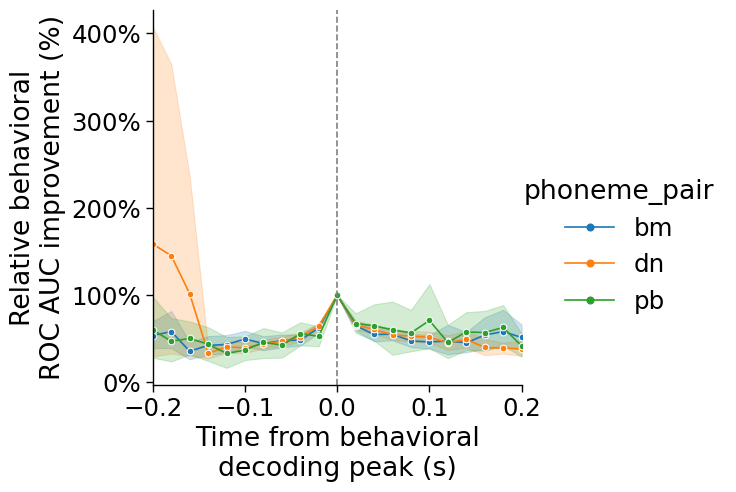

In [184]:
g = sns.relplot(data=behav_relative_df.to_pandas(), x="tmax_relative", y="behav_roc_auc_relative",
                hue="phoneme_pair", hue_order=phoneme_pair_order,
                kind="line", marker="o")
g.set_axis_labels("Time from behavioral\ndecoding peak (s)", "Relative behavioral\nROC AUC improvement (%)")

for ax in g.axes.flat:
    ax.axvline(0, color="gray", ls="--")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.set_xlim(-relative_performance_twidth, relative_performance_twidth)

## Cross-window analysis

### Phon prediction

In [185]:
phon_roc_auc_comparison_df = (
    pl.concat([
        (plot_phon_phon_keys
        .join(phon_roc_auc_searchlight_df,
            on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
            how="left")
        .with_columns(pl.lit("phon").alias("source"))),
        (plot_behav_phon_keys
        .join(phon_roc_auc_searchlight_df,
            on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
            how="left")
        .with_columns(pl.lit("behav").alias("source"))),
    ], how="align")
    .with_columns(
        pl.concat_str(
            [pl.col("subject"), pl.col("electrode_idx").cast(pl.Utf8), pl.col("phoneme_pair")],
            separator="_"
        ).alias("site")
    )
)

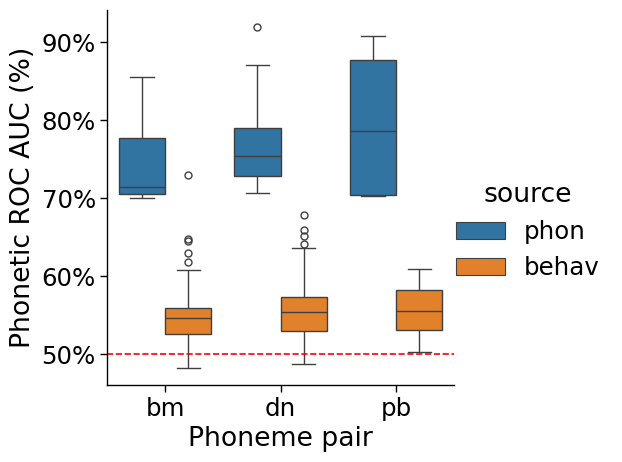

In [186]:
g = sns.catplot(
    data=(
        phon_roc_auc_comparison_df
        .group_by(["source", "site", "subject", "electrode_idx", "phoneme_pair", "smin", "smax"])
        .agg(pl.mean("phon_roc_auc"))
    ).to_pandas(),
    x="phoneme_pair", order=phoneme_pair_order,
    y="phon_roc_auc",
    hue="source", hue_order=source_order,
    kind="box", units="site")
g.set_axis_labels("Phoneme pair", "Phonetic ROC AUC (%)")
for ax in g.axes.flat:
    ax.axhline(0.5, color="red", linestyle="--")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

In [187]:
# from src.viz import spaghetti_plot
# spaghetti_plot(phon_roc_auc_overall.assign(word_end="NA"),
#                y="roc_auc", by1="phon", by2="behav", by="source",
#                col="phoneme_pair")

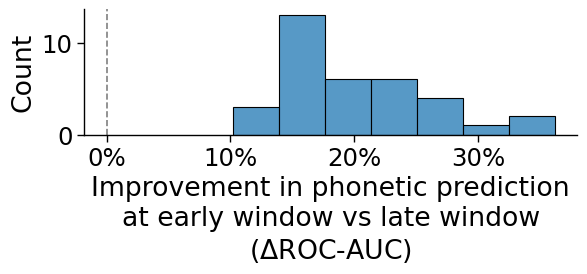

In [188]:
g = sns.displot(
    data=phon_roc_auc_comparison_df.pivot(
            on="source",
            index=["site", "subject", "electrode_idx", "phoneme_pair"],
            values="phon_roc_auc",
            aggregate_function="mean"
        ).filter(pl.col("phon").is_not_null() & pl.col("behav").is_not_null()
        ).with_columns(
            (pl.col("phon") - pl.col("behav")).alias("roc_auc_diff")
        ).to_pandas(),
    x="roc_auc_diff",
    height=2.5, aspect=2.5)
g.set_axis_labels("Improvement in phonetic prediction\nat early window vs late window\n($\\Delta$ROC-AUC)")

for ax in g.axes.flat:
    ax.axvline(0, color="gray", linestyle="--")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

### Behav prediction

In [189]:
behav_roc_auc_comparison_phon = (
    plot_phon_behav_keys
    .join(behav_roc_auc_searchlight_df,
        on=["subject", "electrode_idx", "phoneme_pair", "smin", "smax"],
        how="left")
    .with_columns(pl.lit("phon").alias("source")))

In [190]:
behav_roc_auc_comparison_behav = (
    plot_behav_behav_keys
    .join(behav_roc_auc_searchlight_df,
        on=["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"],
        how="left")
    .with_columns(pl.lit("behav").alias("source")))

In [191]:
behav_roc_auc_comparison_phon.sort(["subject", "electrode_idx", "phoneme_pair", "word_end"])

subject,electrode_idx,phoneme_pair,smin,smax,word_end,fold,behav_roc_auc,behav_roc_auc_baseline,behav_roc_auc_improvement,source
enum,i64,enum,i64,i64,enum,i64,f64,f64,f64,str
"""EC243""",87,"""bm""",47,62,"""bountiful""",0,0.697115,0.711538,-0.014423,"""phon"""
"""EC243""",87,"""bm""",47,62,"""bountiful""",4,0.62987,0.633117,-0.003247,"""phon"""
"""EC243""",87,"""bm""",47,62,"""bountiful""",2,0.779221,0.792208,-0.012987,"""phon"""
"""EC243""",87,"""bm""",47,62,"""bountiful""",3,0.755556,0.769444,-0.013889,"""phon"""
"""EC243""",87,"""bm""",47,62,"""bountiful""",1,0.759615,0.788462,-0.028846,"""phon"""
…,…,…,…,…,…,…,…,…,…,…
"""EC282""",106,"""dn""",47,62,"""necessary""",3,0.954545,0.977273,-0.022727,"""phon"""
"""EC282""",106,"""dn""",47,62,"""necessary""",1,1.0,1.0,0.0,"""phon"""
"""EC282""",106,"""dn""",47,62,"""necessary""",2,0.861111,0.986111,-0.125,"""phon"""


In [192]:
behav_roc_auc_comparison_df = (
    pl.concat([
        behav_roc_auc_comparison_phon,
        behav_roc_auc_comparison_behav,
        behav_baseline_df.with_columns(
            pl.lit("baseline").alias("source"),
            pl.col("behav_roc_auc_baseline").alias("behav_roc_auc"))
    ], how="align")
    .with_columns(
        pl.concat_str(
            [pl.col("subject"), pl.col("electrode_idx").cast(pl.Utf8), pl.col("phoneme_pair")],
            separator="_"
        ).alias("site"))
)

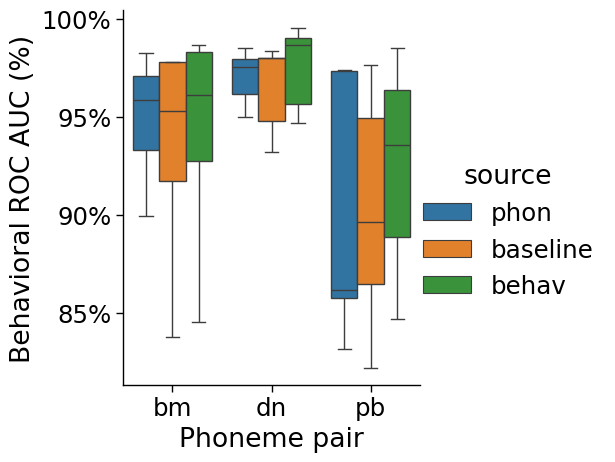

In [193]:
g = sns.catplot(
    data=(
        behav_roc_auc_comparison_df
        .group_by(["source", "site", "subject", "electrode_idx", "phoneme_pair", "smin", "smax"])
        .agg(pl.mean("behav_roc_auc"))
    ).to_pandas(),
    x="phoneme_pair", order=phoneme_pair_order,
    y="behav_roc_auc",
    hue="source", hue_order=["phon", "baseline", "behav"], kind="box",
    showfliers=False)
g.set_axis_labels("Phoneme pair", "Behavioral ROC AUC (%)")
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

In [194]:
# spaghetti_plot(behav_roc_auc_overall.query("source in ['phon', 'behav']"),
#                y="roc_auc", by1="phon", by2="behav", by="source",
#                col="phoneme_pair")

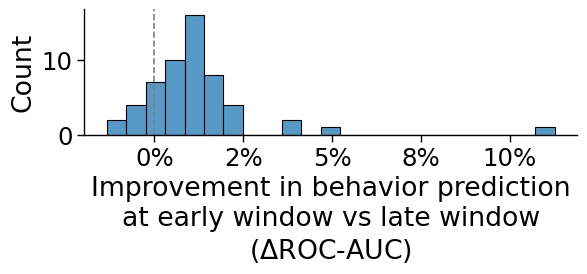

In [195]:
g = sns.displot(data=
    (behav_roc_auc_comparison_df
     .pivot(
         on="source",
         index=["subject", "electrode_idx", "phoneme_pair", "word_end"],
         values="behav_roc_auc",
         aggregate_function="mean")
     .filter(pl.col("phon").is_not_null() & pl.col("behav").is_not_null() & pl.col("baseline").is_not_null())
     .with_columns((pl.col("behav") - pl.col("baseline")).alias("behav_baseline_diff"),
                   (pl.col("phon") - pl.col("baseline")).alias("phon_baseline_diff"),
                   (pl.col("behav") - pl.col("phon")).alias("behav_phon_diff"))
    #  .unpivot(
    #         index=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    #         on=["behav_baseline_diff", "phon_baseline_diff", "behav_phon_diff"],
    #         variable_name="comparison",
    #         value_name="improvement"
    #  )
     ).to_pandas(),
    # x="improvement", row="comparison",
    x="behav_phon_diff",
    height=2.5, aspect=2.5)
g.set_axis_labels("Improvement in behavior prediction\nat early window vs late window\n($\\Delta$ROC-AUC)")

for ax in g.axes.flat:
    ax.axvline(0, color="gray", linestyle="--")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

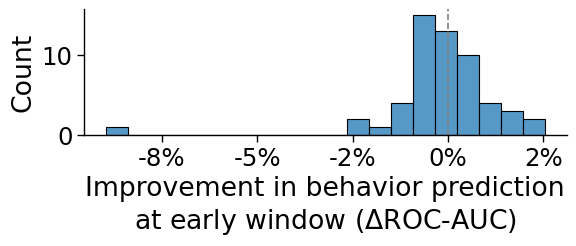

In [196]:
g = sns.displot(data=
    (behav_roc_auc_comparison_df
     .pivot(
         on="source",
         index=["subject", "electrode_idx", "phoneme_pair", "word_end"],
         values="behav_roc_auc",
         aggregate_function="mean")
     .filter(pl.col("phon").is_not_null() & pl.col("behav").is_not_null() & pl.col("baseline").is_not_null())
     .with_columns((pl.col("behav") - pl.col("baseline")).alias("behav_baseline_diff"),
                   (pl.col("phon") - pl.col("baseline")).alias("phon_baseline_diff"),
                   (pl.col("behav") - pl.col("phon")).alias("behav_phon_diff"))
    #  .unpivot(
    #         index=["subject", "electrode_idx", "phoneme_pair", "word_end"],
    #         on=["behav_baseline_diff", "phon_baseline_diff", "behav_phon_diff"],
    #         variable_name="comparison",
    #         value_name="improvement"
    #  )
     ).to_pandas(),
    # x="improvement", row="comparison",
    x="phon_baseline_diff",
    height=2.5, aspect=2.5)
g.set_axis_labels("Improvement in behavior prediction\nat early window ($\\Delta$ROC-AUC)")

for ax in g.axes.flat:
    ax.axvline(0, color="gray", linestyle="--")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

### Cross-window transfer, no training

#### Phonetic

In [204]:
(
    phon_roc_auc_comparison_df
    .filter(pl.col("source") == "behav")
    .group_by(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"])
    .agg(pl.mean("phon_roc_auc"))
    .sort("phon_roc_auc", descending=True)
    .filter(pl.col("phon_roc_auc") > 0.65)
)

subject,electrode_idx,phoneme_pair,word_end,smin,smax,phon_roc_auc
enum,i64,enum,enum,i64,i64,f64
"""EC250""",216,"""bm""","""bountiful""",73,88,0.729331
"""EC282""",84,"""dn""","""necessary""",79,94,0.677778
"""EC253""",181,"""dn""","""necessary""",131,146,0.658989
"""EC250""",216,"""dn""","""desolate""",71,86,0.651572


#### Behavior

In [198]:
(
    behav_roc_auc_comparison_phon
    .group_by(["subject", "electrode_idx", "phoneme_pair", "word_end", "smin", "smax"])
    .agg(pl.mean("behav_roc_auc_improvement"))
    .sort("behav_roc_auc_improvement", descending=True)
    .filter(pl.col("behav_roc_auc_improvement") > 0.01)
)

subject,electrode_idx,phoneme_pair,word_end,smin,smax,behav_roc_auc_improvement
enum,i64,enum,enum,i64,i64,f64
"""EC243""",87,"""dn""","""desolate""",49,64,0.025353
"""EC250""",191,"""bm""","""mountains""",45,60,0.021239
"""EC243""",102,"""dn""","""desolate""",53,68,0.016845
"""EC243""",102,"""dn""","""necessary""",53,68,0.016147
"""EC250""",216,"""bm""","""bountiful""",51,66,0.015391
"""EC250""",216,"""bm""","""mountains""",51,66,0.011605


In [199]:
# TODO transfer analysis on these

## Zoomin

In [200]:
phon_peaks_df.join(behav_peaks_df,
    on=["subject", "electrode_idx", "phoneme_pair"]) \
    .sort("phon_roc_auc", descending=True) \
    .select(["subject", "electrode_idx", "phoneme_pair", "word_end", "phon_roc_auc", "behav_roc_auc_improvement"]) \
    .head(30)

subject,electrode_idx,phoneme_pair,word_end,phon_roc_auc,behav_roc_auc_improvement
enum,i64,enum,enum,f64,f64
"""EC250""",215,"""dn""","""necessary""",0.919145,0.007782
"""EC253""",21,"""pb""","""beneficial""",0.906867,0.00225
"""EC253""",21,"""pb""","""penecillin""",0.906867,0.008485
"""EC250""",215,"""pb""","""beneficial""",0.876852,0.016328
"""EC282""",84,"""dn""","""necessary""",0.870332,0.018769
…,…,…,…,…,…
"""EC250""",185,"""dn""","""necessary""",0.777276,0.005906
"""EC282""",84,"""bm""","""mountains""",0.776273,0.013636
"""EC282""",84,"""bm""","""bountiful""",0.776273,0.011496


In [201]:
def zoomin(subject, electrode_idx, phoneme_pair):
    # phonetic predictions
    subplot_phon_phon_df = (
        plot_phon_phon_df.filter(
            (pl.col("electrode_idx") == electrode_idx) &
            (pl.col("subject") == subject) &
            (pl.col("phoneme_pair") == phoneme_pair)
        )
    )
    subplot_behav_phon_df = (
        plot_behav_phon_df.filter(
            (pl.col("electrode_idx") == electrode_idx) &
            (pl.col("subject") == subject) &
            (pl.col("phoneme_pair") == phoneme_pair)
        )
    )

    # behav predictions
    subplot_behav_behav_df = (
        plot_behav_behav_df.filter(
            (pl.col("electrode_idx") == electrode_idx) &
            (pl.col("subject") == subject) &
            (pl.col("phoneme_pair") == phoneme_pair)
        )
    )
    subplot_phon_behav_df = (
        plot_phon_behav_df.filter(
            (pl.col("electrode_idx") == electrode_idx) &
            (pl.col("subject") == subject) &
            (pl.col("phoneme_pair") == phoneme_pair)
        )
    )

    assert subplot_phon_phon_df.select(pl.n_unique("smin")).item() == 1
    assert subplot_behav_phon_df.group_by("word_end").agg(pl.n_unique("smin")).select(pl.max("smin")).item() == 1
    assert subplot_behav_behav_df.group_by("word_end").agg(pl.n_unique("smin")).select(pl.max("smin")).item() == 1
    assert subplot_phon_behav_df.select(pl.n_unique("smin")).item() == 1

    # assert subplot_phon_phon_df.smin.nunique() == 1
    # assert subplot_behav_phon_df.groupby("word_end").smin.nunique().max() == 1
    # assert subplot_behav_behav_df.groupby("word_end").smin.nunique().max() == 1
    # assert subplot_phon_behav_df.smin.nunique() == 1

    subplot_phon_df = pl.concat([
        subplot_phon_phon_df.with_columns(pl.lit("phon").alias("source")),
        subplot_behav_phon_df.with_columns(pl.lit("behav").alias("source")),
    ])

    subplot_behav_df = pl.concat([
        subplot_phon_behav_df.with_columns(pl.lit("phon").alias("source")),
        subplot_behav_behav_df.with_columns(pl.lit("behav").alias("source")),
    ], how="align").join(all_md, on=["subject", "epoch_idx", "phoneme_pair", "word_end"], how="left")

    print("Phonetic window:", subplot_phon_phon_df.select(pl.min("smin")).item(), "-", subplot_phon_phon_df.select(pl.max("smax")).item())
    print("Behavioral window:", subplot_behav_behav_df.select(pl.min("smin")).item(), "-", subplot_behav_behav_df.select(pl.max("smax")).item())

    # sub_phon_acc_change = phon_acc_change.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    # sub_behav_roc_auc = behav_roc_auc.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")
    # sub_behav_roc_auc_improvement = behav_roc_auc_improvement.query(f"electrode_idx== {electrode_idx} and subject == '{subject}' and phoneme_pair == '{phoneme_pair}'")

    # # Also compute overall phonetic and behavioral ROC-AUC
    # phon_phon_roc_auc = roc_auc_score(subplot_phon_phon_df.decoder_target, subplot_phon_phon_df.decoder_proba)
    # behav_phon_roc_auc = roc_auc_score(subplot_behav_phon_df.decoder_target, subplot_behav_phon_df.decoder_proba)
    # behav_behav_roc_auc = roc_auc_score(subplot_behav_behav_df.decoder_target, subplot_behav_behav_df.full_decoder_proba)
    # phon_behav_roc_auc = roc_auc_score(subplot_phon_behav_df.decoder_target, subplot_phon_behav_df.full_decoder_proba)
    # roc_auc_heatmap_df = pd.DataFrame({
    #     "source": ["phon", "phon", "behav", "behav"],
    #     "target": ["phon", "behav", "phon", "behav"],
    #     "roc_auc": [phon_phon_roc_auc, phon_behav_roc_auc, behav_phon_roc_auc, behav_behav_roc_auc]
    # }).pivot(index="source", columns="target", values="roc_auc")

    # f, ax = plt.subplots(figsize=(4, 4))
    # sns.heatmap(roc_auc_heatmap_df, annot=True, vmin=0.5, vmax=1.0, cmap="Blues", ax=ax)

    g_phon = sns.catplot(
        data=subplot_phon_df.to_pandas(),
        x="resampled", y="decoder_proba", hue="lexical_evidence",
        col="source", col_order=["phon", "behav"],
        kind="point", height=4)
    for ax in g_phon.axes.flat:
        ax.axhline(0.5, color="red", linestyle="--")

    # g_phon_acc_change = sns.catplot(
    #     data=sub_phon_acc_change,
    #     x="resampled", y="acc_diff", hue="lexical_evidence",
    #     kind="point", height=3)
    # g_phon_acc_change.figure.suptitle("Improvement in phonetic decoding\nat phon - behav window")
    # for ax in g_phon_acc_change.axes.flat:
    #     ax.axhline(0, color="red", linestyle="--")

    g_behav = sns.catplot(
        data=subplot_behav_df.to_pandas(),
        x="resampled", y="full_decoder_proba", hue="decoder_target",
        col="source", col_order=["phon", "behav"],
        kind="point", height=4)
    for ax in g_behav.axes.flat:
        ax.axhline(0.5, color="red", linestyle="--")

    # g_behav_roc_auc = sns.catplot(
    #     data=sub_behav_roc_auc,
    #     x="resampled", y="roc_auc",
    #     hue="source", col="word_end",
    #     kind="point", height=3)
    # g_behav_roc_auc.set_axis_labels("Resampled", "ROC AUC")
    # for ax in g_behav_roc_auc.axes.flat:
    #     ax.axhline(0.5, color="red", linestyle="--")

    # g_behav_roc_auc_improvement = sns.catplot(
    #     data=sub_behav_roc_auc_improvement,
    #     x="resampled", y="roc_auc",
    #     hue="source", col="word_end",
    #     kind="point", height=3)
    # g_behav_roc_auc_improvement.set_axis_labels("Resampled", "ROC AUC Improvement\nover Baseline")
    # for ax in g_behav_roc_auc_improvement.axes.flat:
    #     ax.axhline(0, color="red", linestyle="--")

    return g_phon, g_behav
    # return g_phon, g_phon_acc_change, g_behav, g_behav_roc_auc, g_behav_roc_auc_improvement

Phonetic window: 53 - 68
Behavioral window: 131 - 146


(<seaborn.axisgrid.FacetGrid at 0x7fe6dbbe1b10>,
 <seaborn.axisgrid.FacetGrid at 0x7fe6dbb10210>)

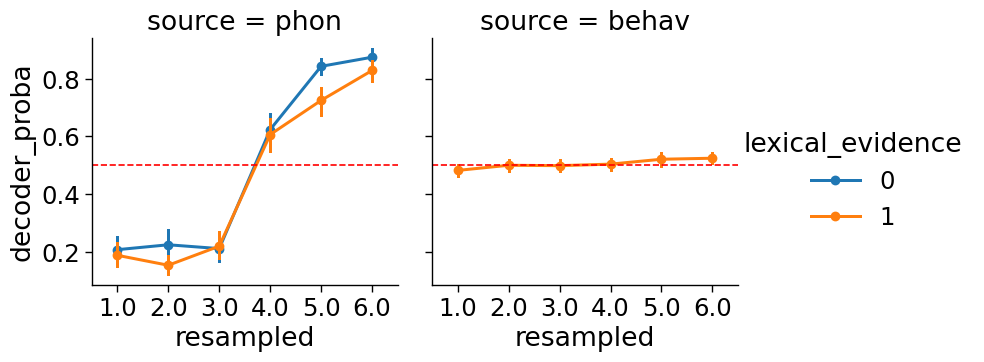

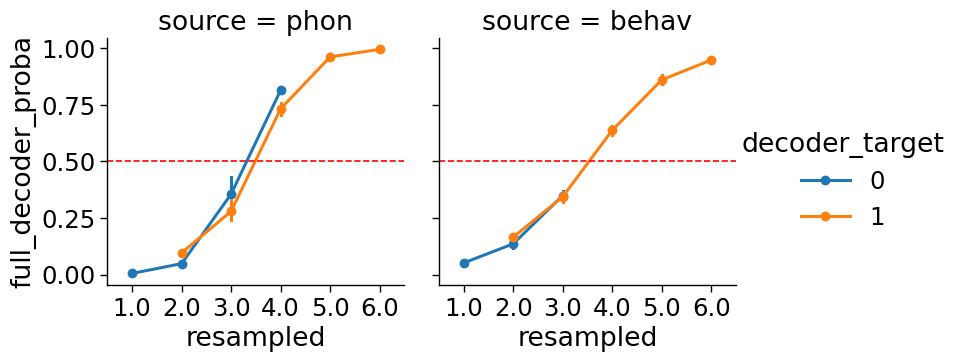

In [202]:
zoomin("EC250", 215, "dn")